<a href="https://colab.research.google.com/github/massengineer/FYP-ML-Bird-Scarer/blob/main/FYP_YOLO_Sixth_Model_v4_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Sun Apr 12 13:26:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.1 MB/s eta 0:00:00


##Install YOLOv8

In [3]:
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display
display.clear_output()
!yolo checks

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)

OS                     Linux-6.6.113+-x86_64-with-glibc2.35
Environment            Colab
Python                 3.12.13
Install                pip
Path                   /usr/local/lib/python3.12/dist-packages/ultralytics
RAM                    12.67 GB
Disk                   43.1/112.6 GB
CPU                    Intel Xeon CPU @ 2.00GHz
CPU count              2
GPU                    Tesla T4, 14913MiB
GPU count              1
CUDA                   12.8

numpy                  ✅ 2.0.2>=1.23.0
matplotlib             ✅ 3.10.0>=3.3.0
opencv-python          ✅ 4.13.0.92>=4.6.0
pillow                 ✅ 11.3.0>=7.1.2
pyyaml                 ✅ 6.0.3>=5.3.1
requests               ✅ 2.32.4>=2.23.0
scipy                  ✅ 1.16.3>=1.4.1
torch                  ✅ 2.10.0+cu128>=1.8.0
torch                  ✅ 2.10.0+cu128!=2.4.0,>=1.8.0; sys_platform == "win32

##Train YOLOv8 Model on Custom Dataset

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ROBOFLOW_API_KEY")
project = rf.workspace("louiss-workspace-dvwey").project("fyp-intelligent-bird-scarer-5")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 107.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to FYP-Intelligent-Bird-Scarer-5-1 in yolov8:: 100%|██████████| 733/733 [00:00<00:00, 6487.46it/s]


In [5]:
!yolo detect train data=/content/FYP-Intelligent-Bird-Scarer-5-1/data.yaml model=yolov8s.pt epochs=150 patience=50 batch=16 imgsz=640

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FYP-Intelligent-Bird-Scarer-5-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

In [6]:
!yolo detect val model=/content/runs/detect/train/weights/best.pt data=/content/FYP-Intelligent-Bird-Scarer-5-1/data.yaml

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2336.2±777.5 MB/s, size: 116.9 KB)
val: Scanning /content/FYP-Intelligent-Bird-Scarer-5-1/valid/labels.cache... 71 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 14.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.7it/s 3.0s
                   all         71         90      0.926      0.747      0.806       0.66
                  duck         16         29      0.944      0.582      0.652      0.535
                 raven         30         39      0.979      0.795      0.866      0.775
               sparrow         19         22      0.853      0.864      0.899       0.67
Speed: 9.0ms preprocess, 13.8ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/de

In [7]:
!yolo detect predict model=/content/runs/detect/train/weights/best.pt conf=0.5 source=/content/FYP-Intelligent-Bird-Scarer-5-1/test/images

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs

image 1/35 /content/FYP-Intelligent-Bird-Scarer-5-1/test/images/00ba3d4a61b04eec_jpg.rf.0d2e3429d50be6b66daad51153c0a0fc.jpg: 640x640 1 raven, 18.9ms
image 2/35 /content/FYP-Intelligent-Bird-Scarer-5-1/test/images/0110c5092753827f_jpg.rf.35c409d17e8469acd2167b27f71d8b6c.jpg: 640x640 2 ducks, 16.2ms
image 3/35 /content/FYP-Intelligent-Bird-Scarer-5-1/test/images/01297ff3e3d45ebf_jpg.rf.d7f46096fb75e4237db39a3adee3b9a9.jpg: 640x640 1 duck, 16.2ms
image 4/35 /content/FYP-Intelligent-Bird-Scarer-5-1/test/images/0715efc2cc093401_jpg.rf.520bc036e3ebedace5301a5ec06140f3.jpg: 640x640 1 duck, 16.3ms
image 5/35 /content/FYP-Intelligent-Bird-Scarer-5-1/test/images/155a996dacd85053_jpg.rf.1f4cc7d401cd927f6041cba936282972.jpg: 640x640 1 raven, 16.3ms
image 6/35 /content/FYP-Intelligent-Bird-Scarer-5-1/test/images/254e73a0d151cc41_jpg.r

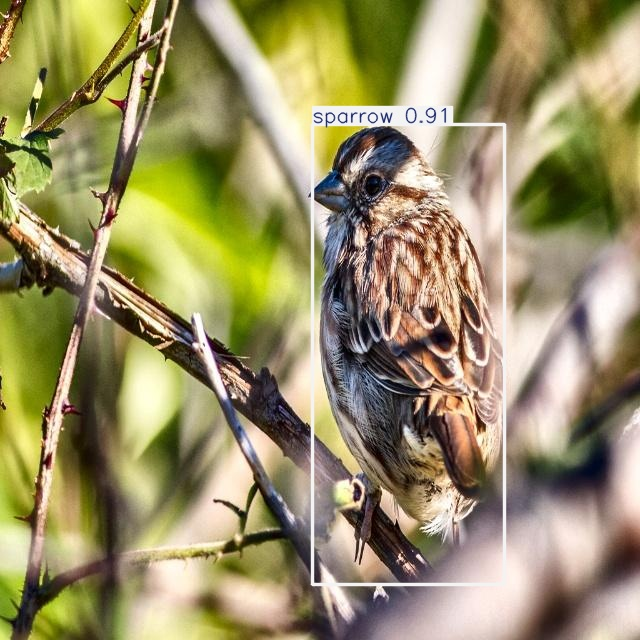

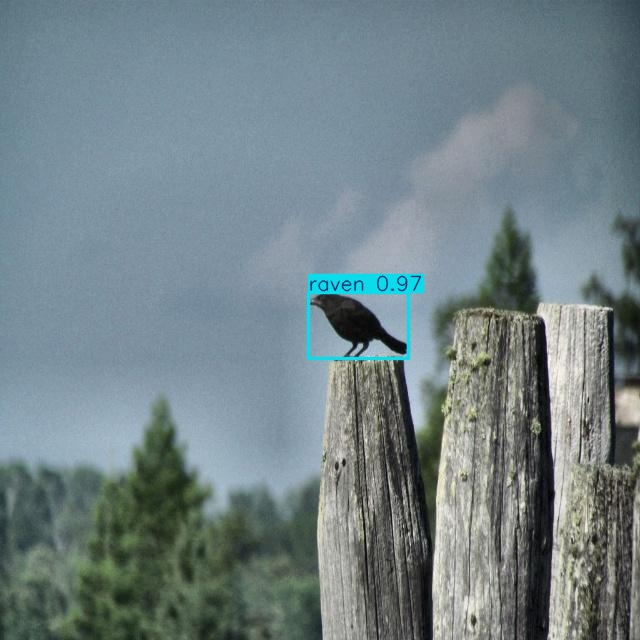

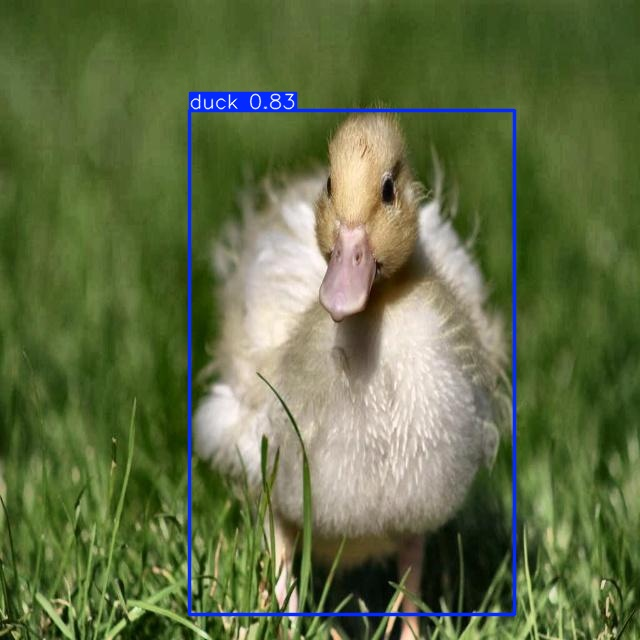

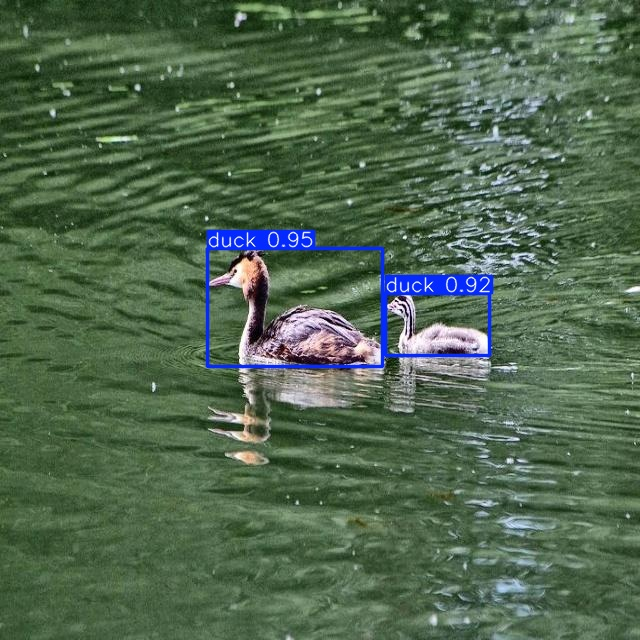

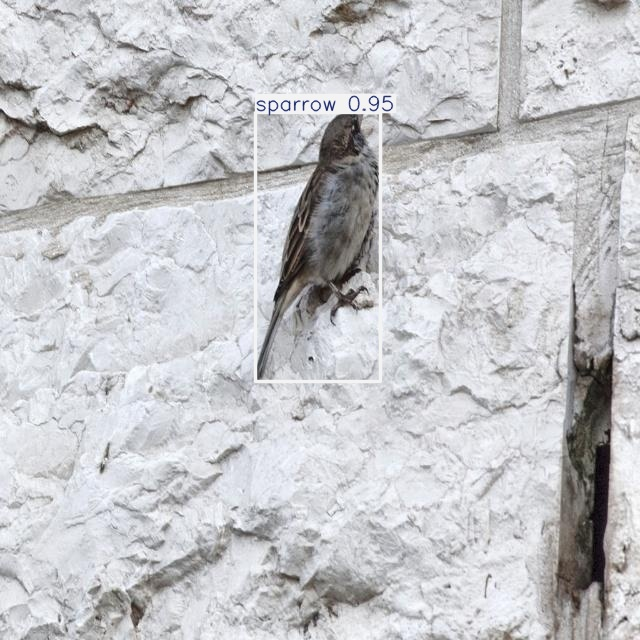

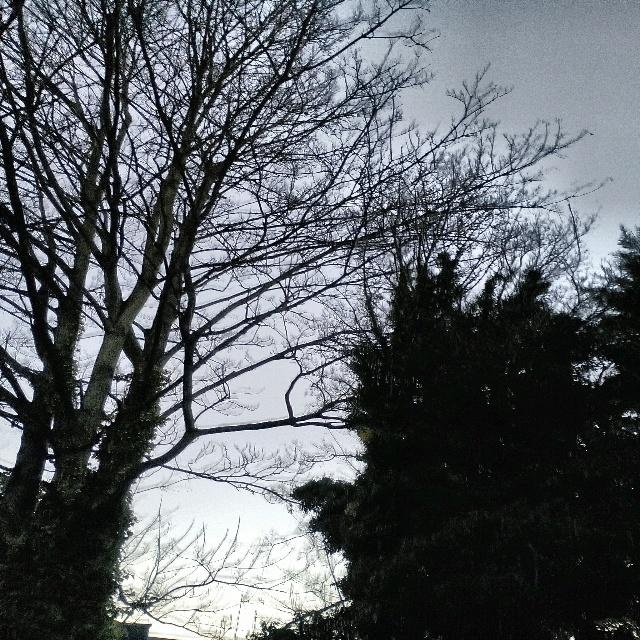

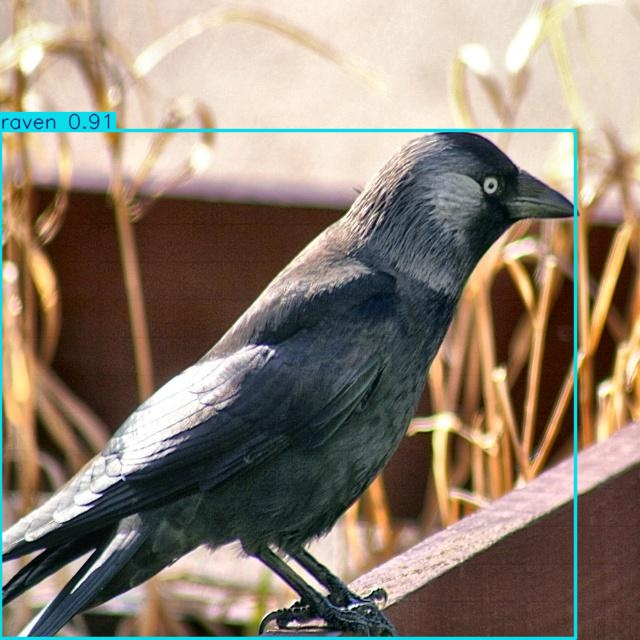

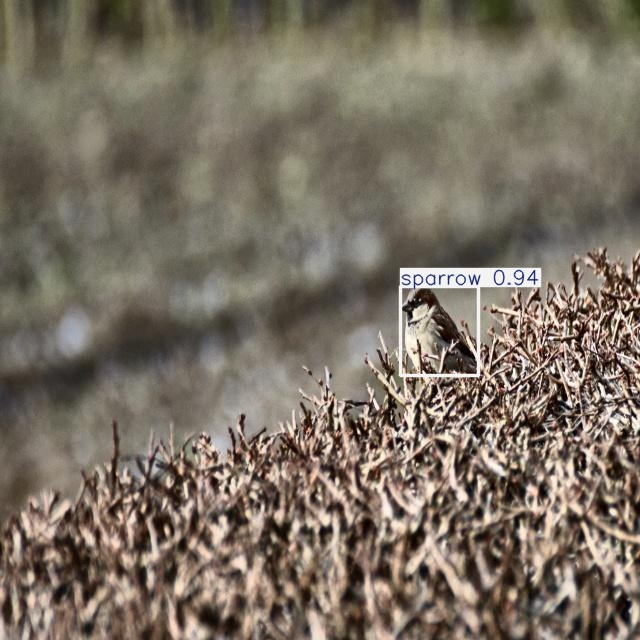

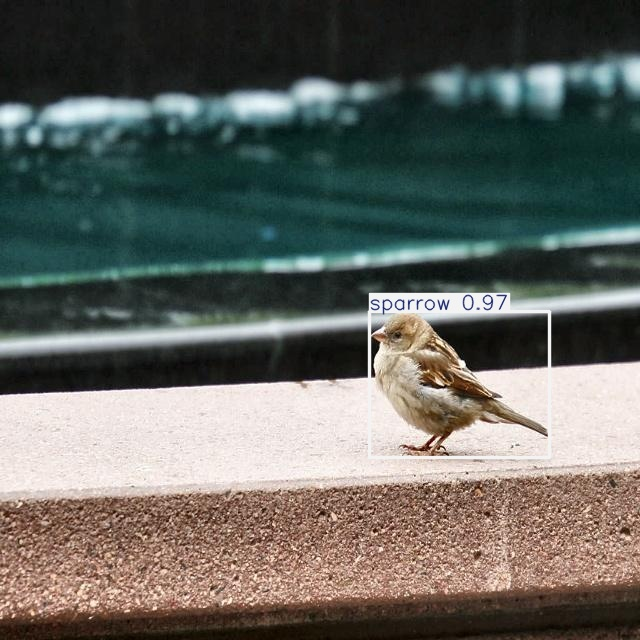

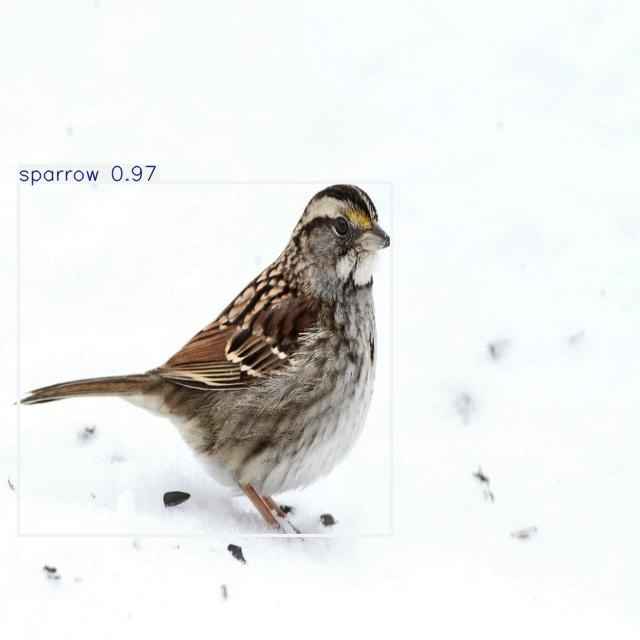

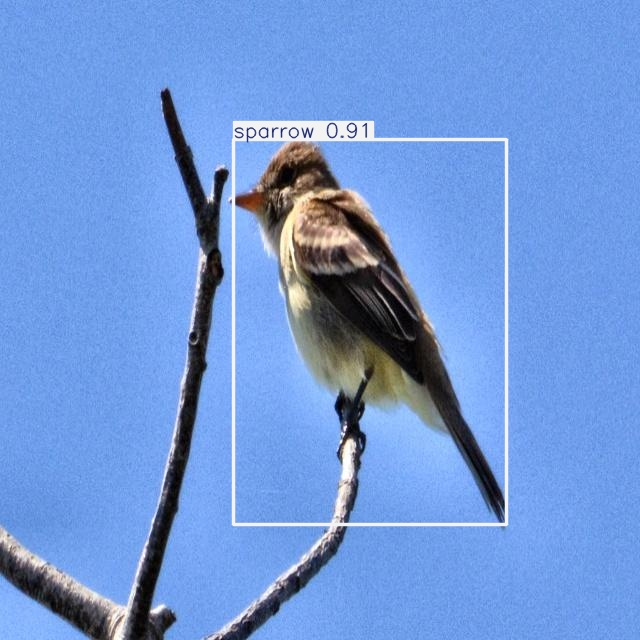

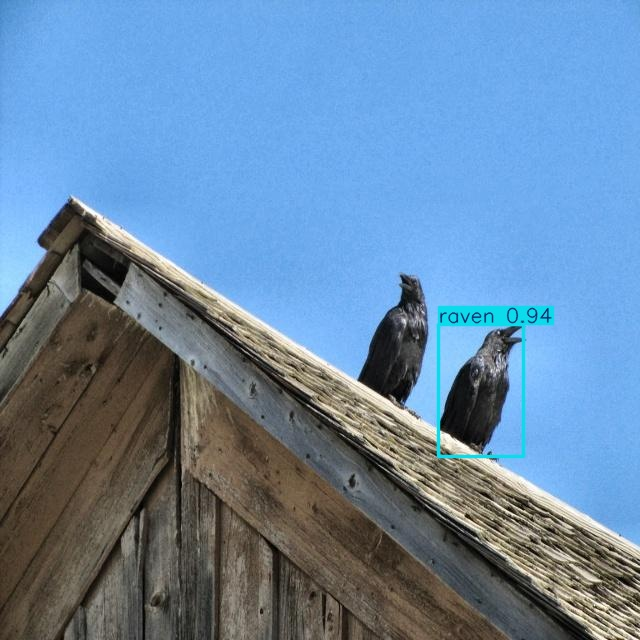

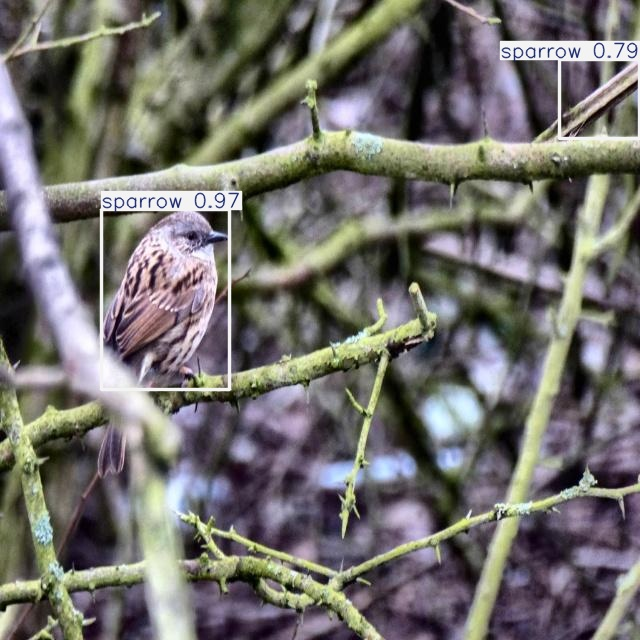

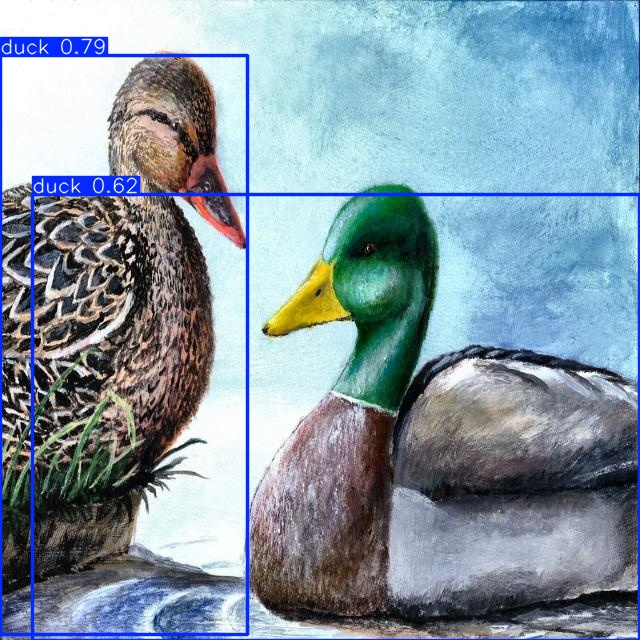

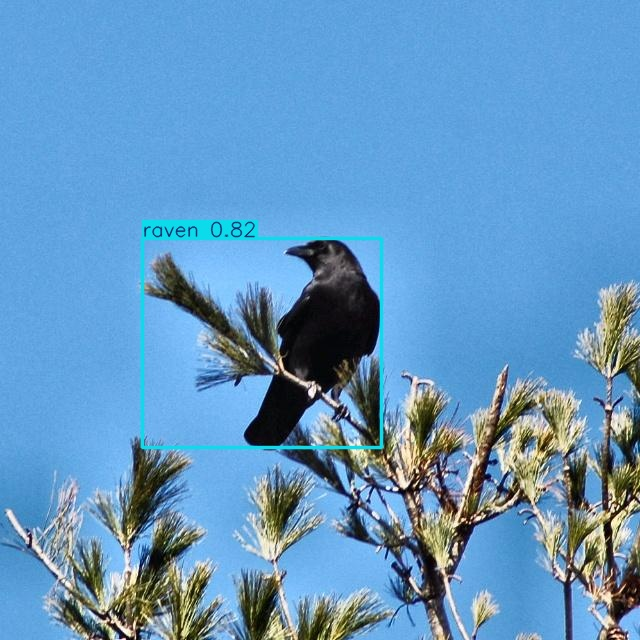

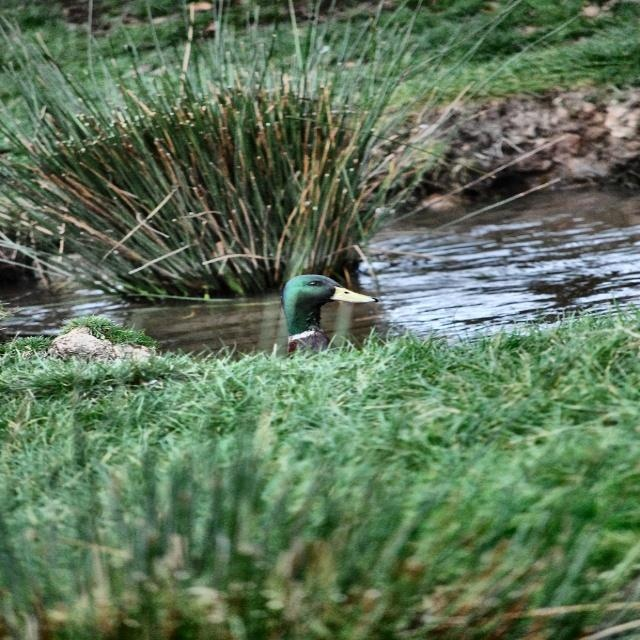

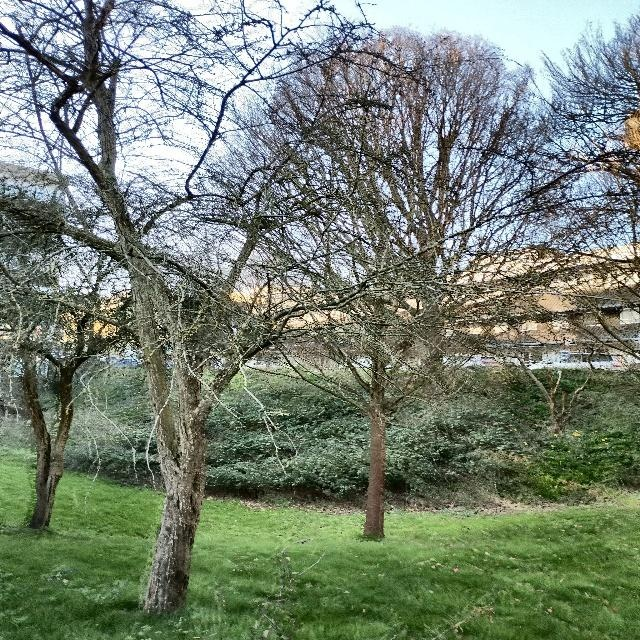

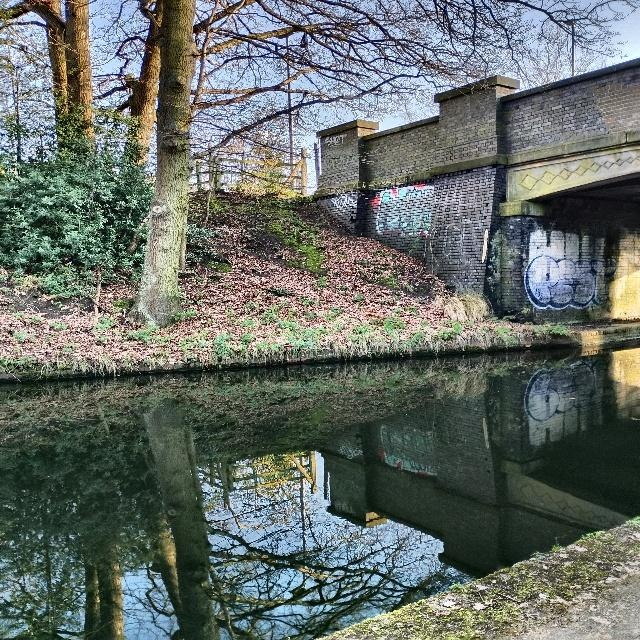

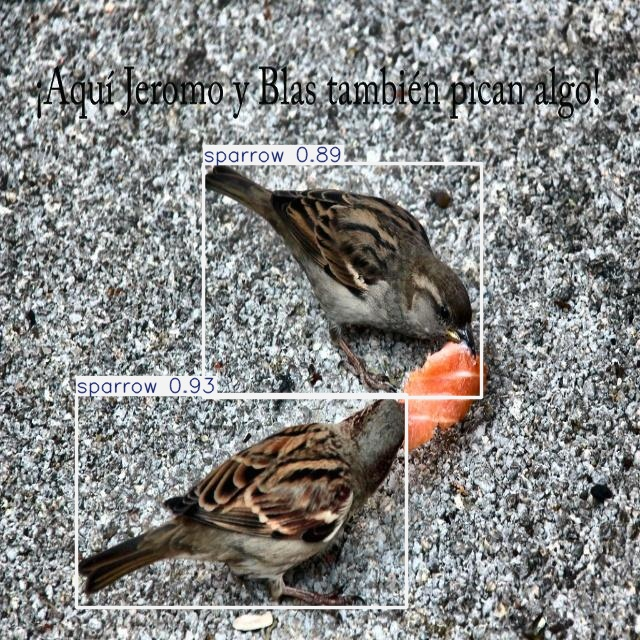

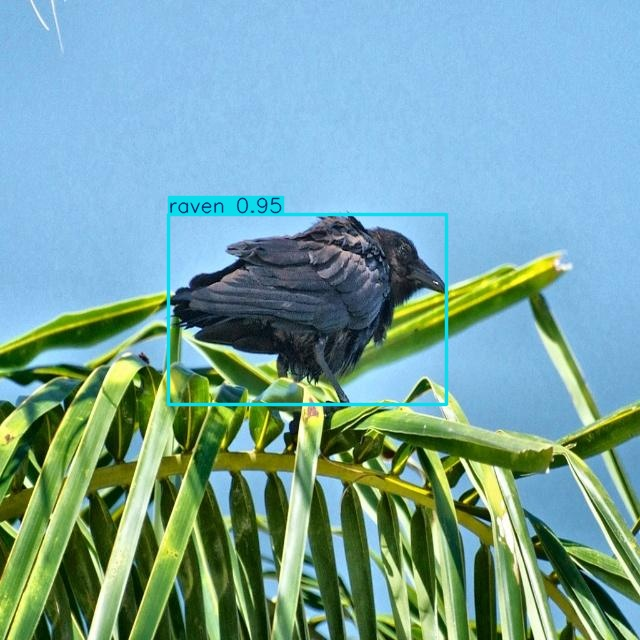

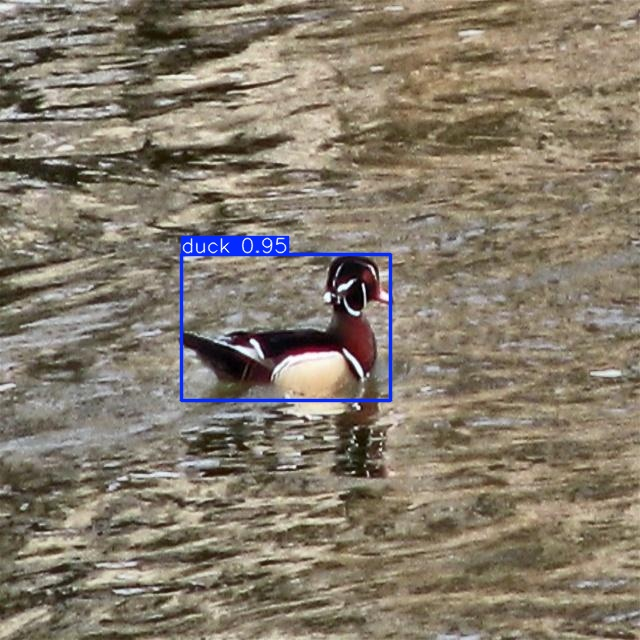

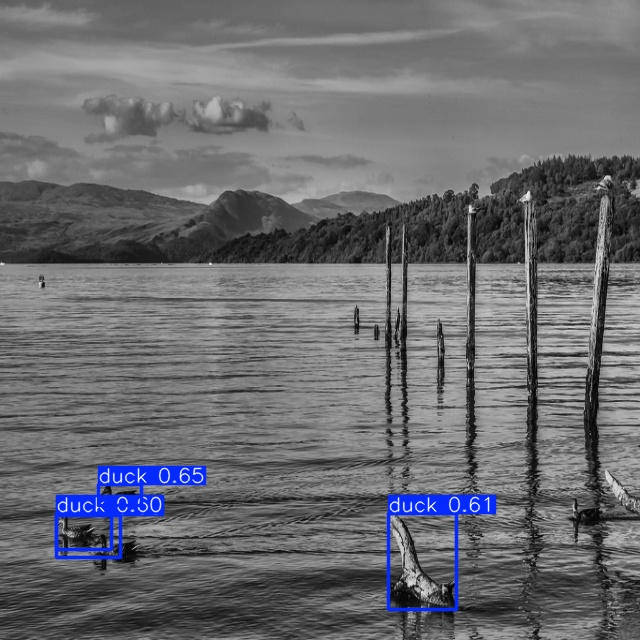

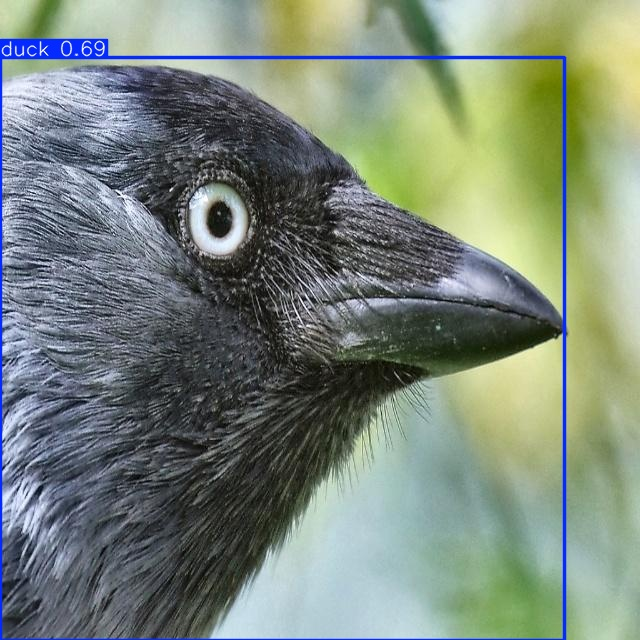

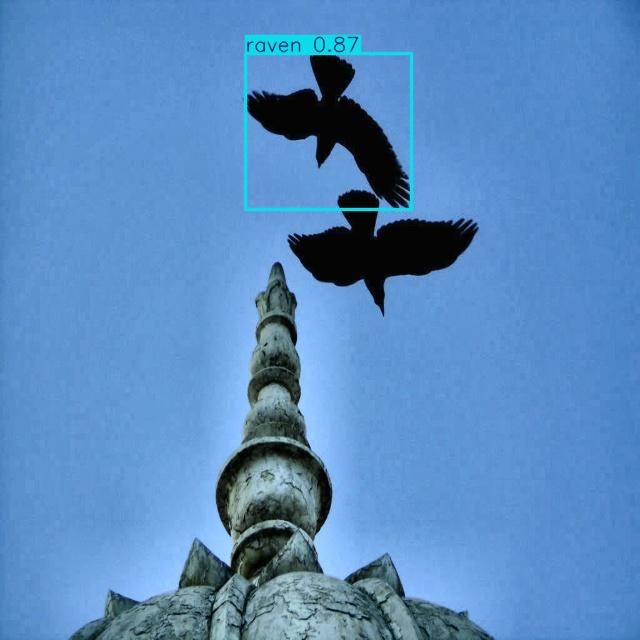

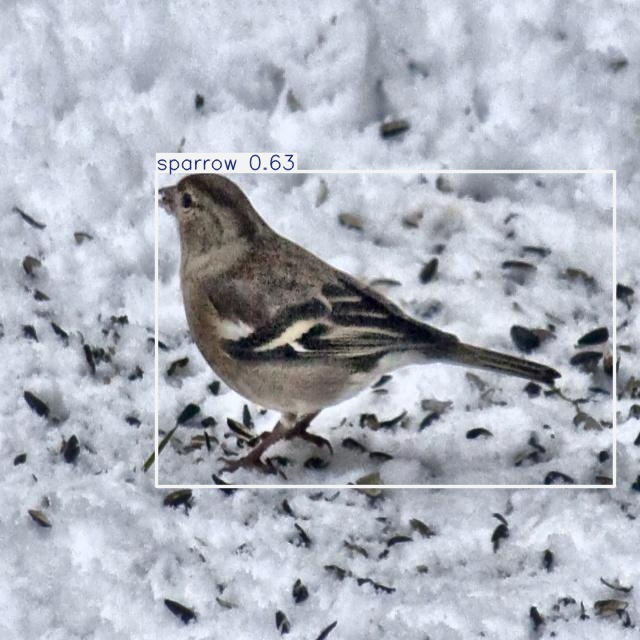

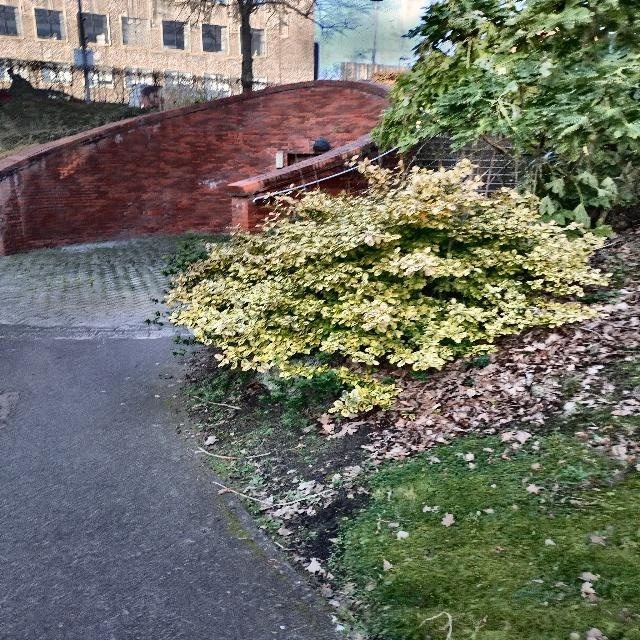

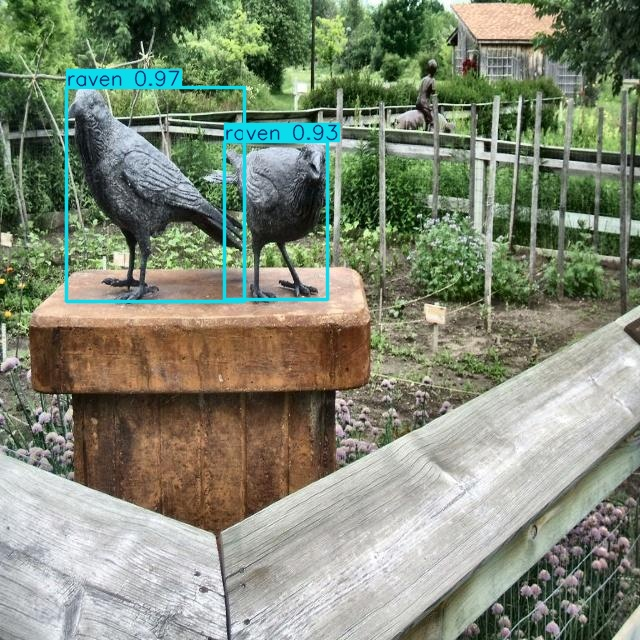

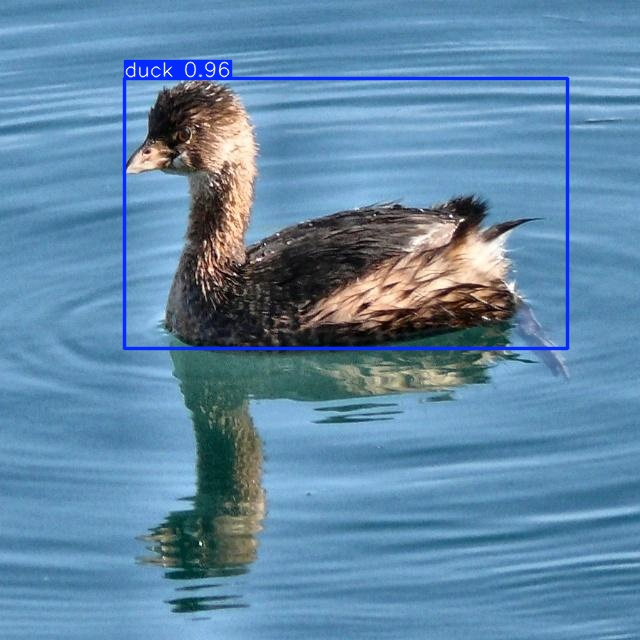

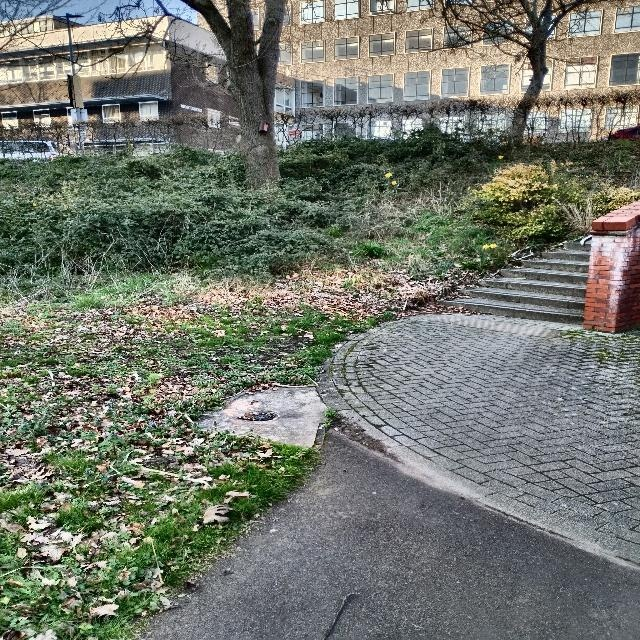

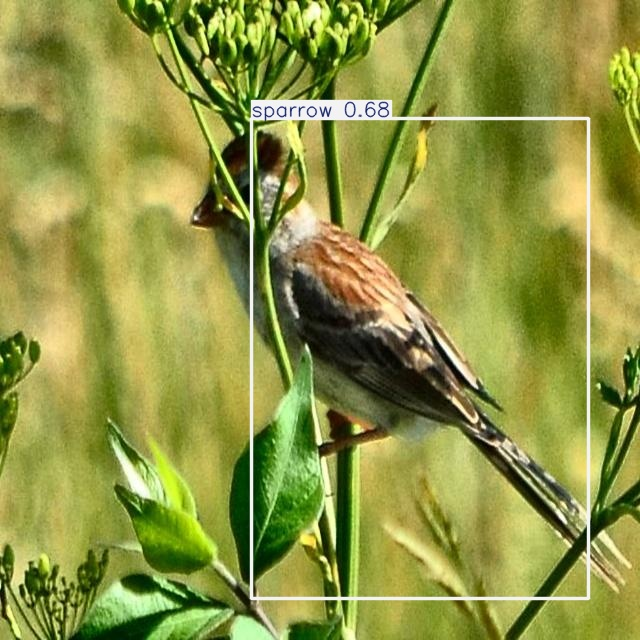

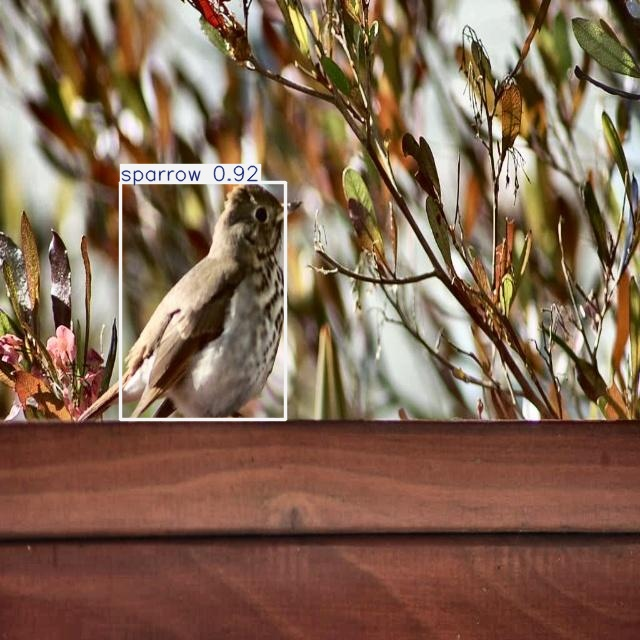

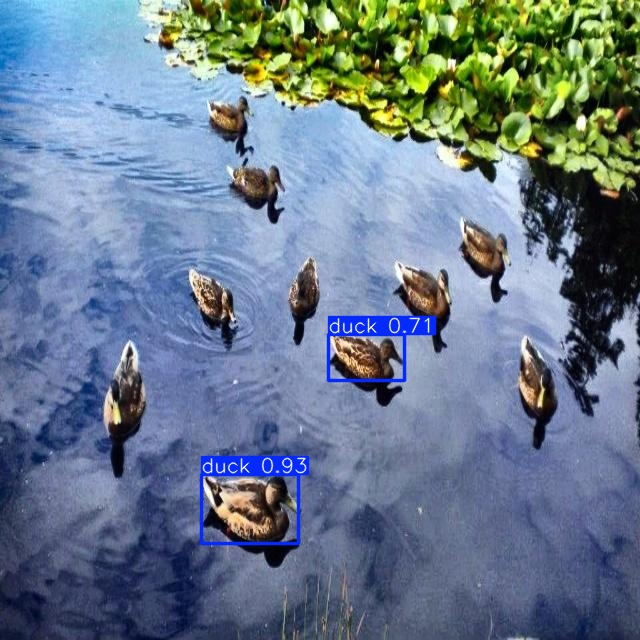

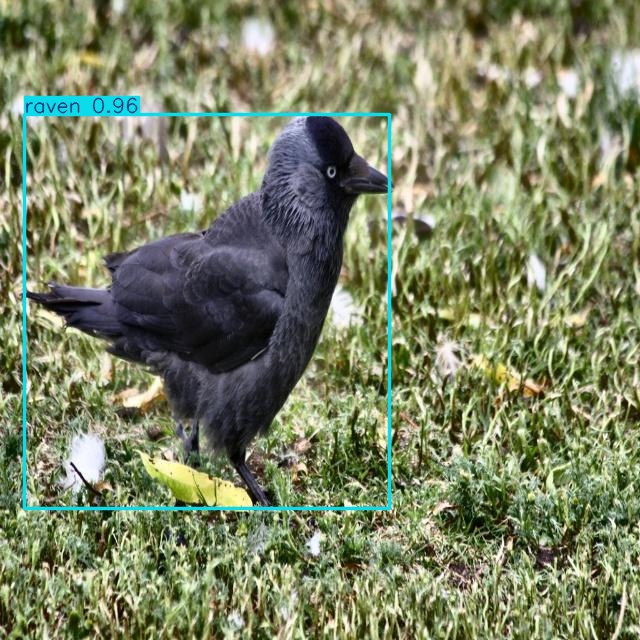

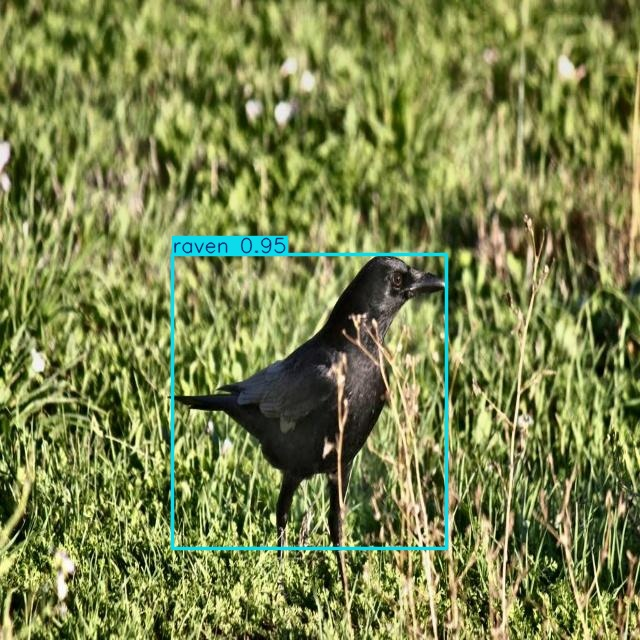

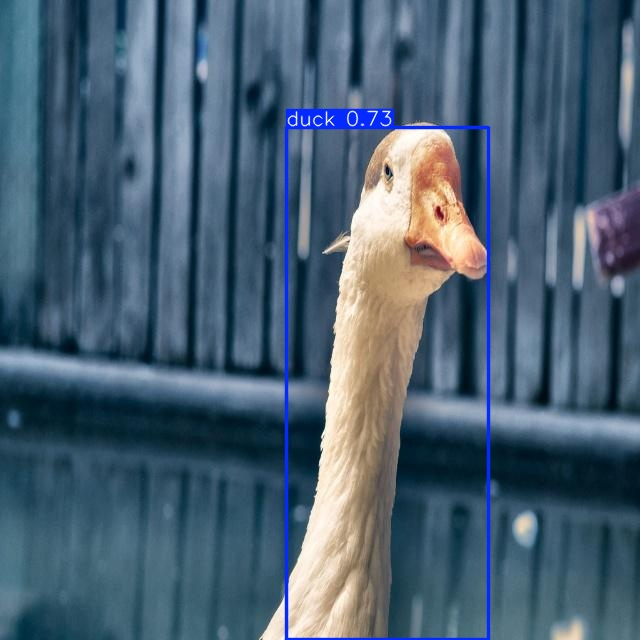

In [8]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg'):
  display(Image(filename=image_path, height=600))
  print('\n')

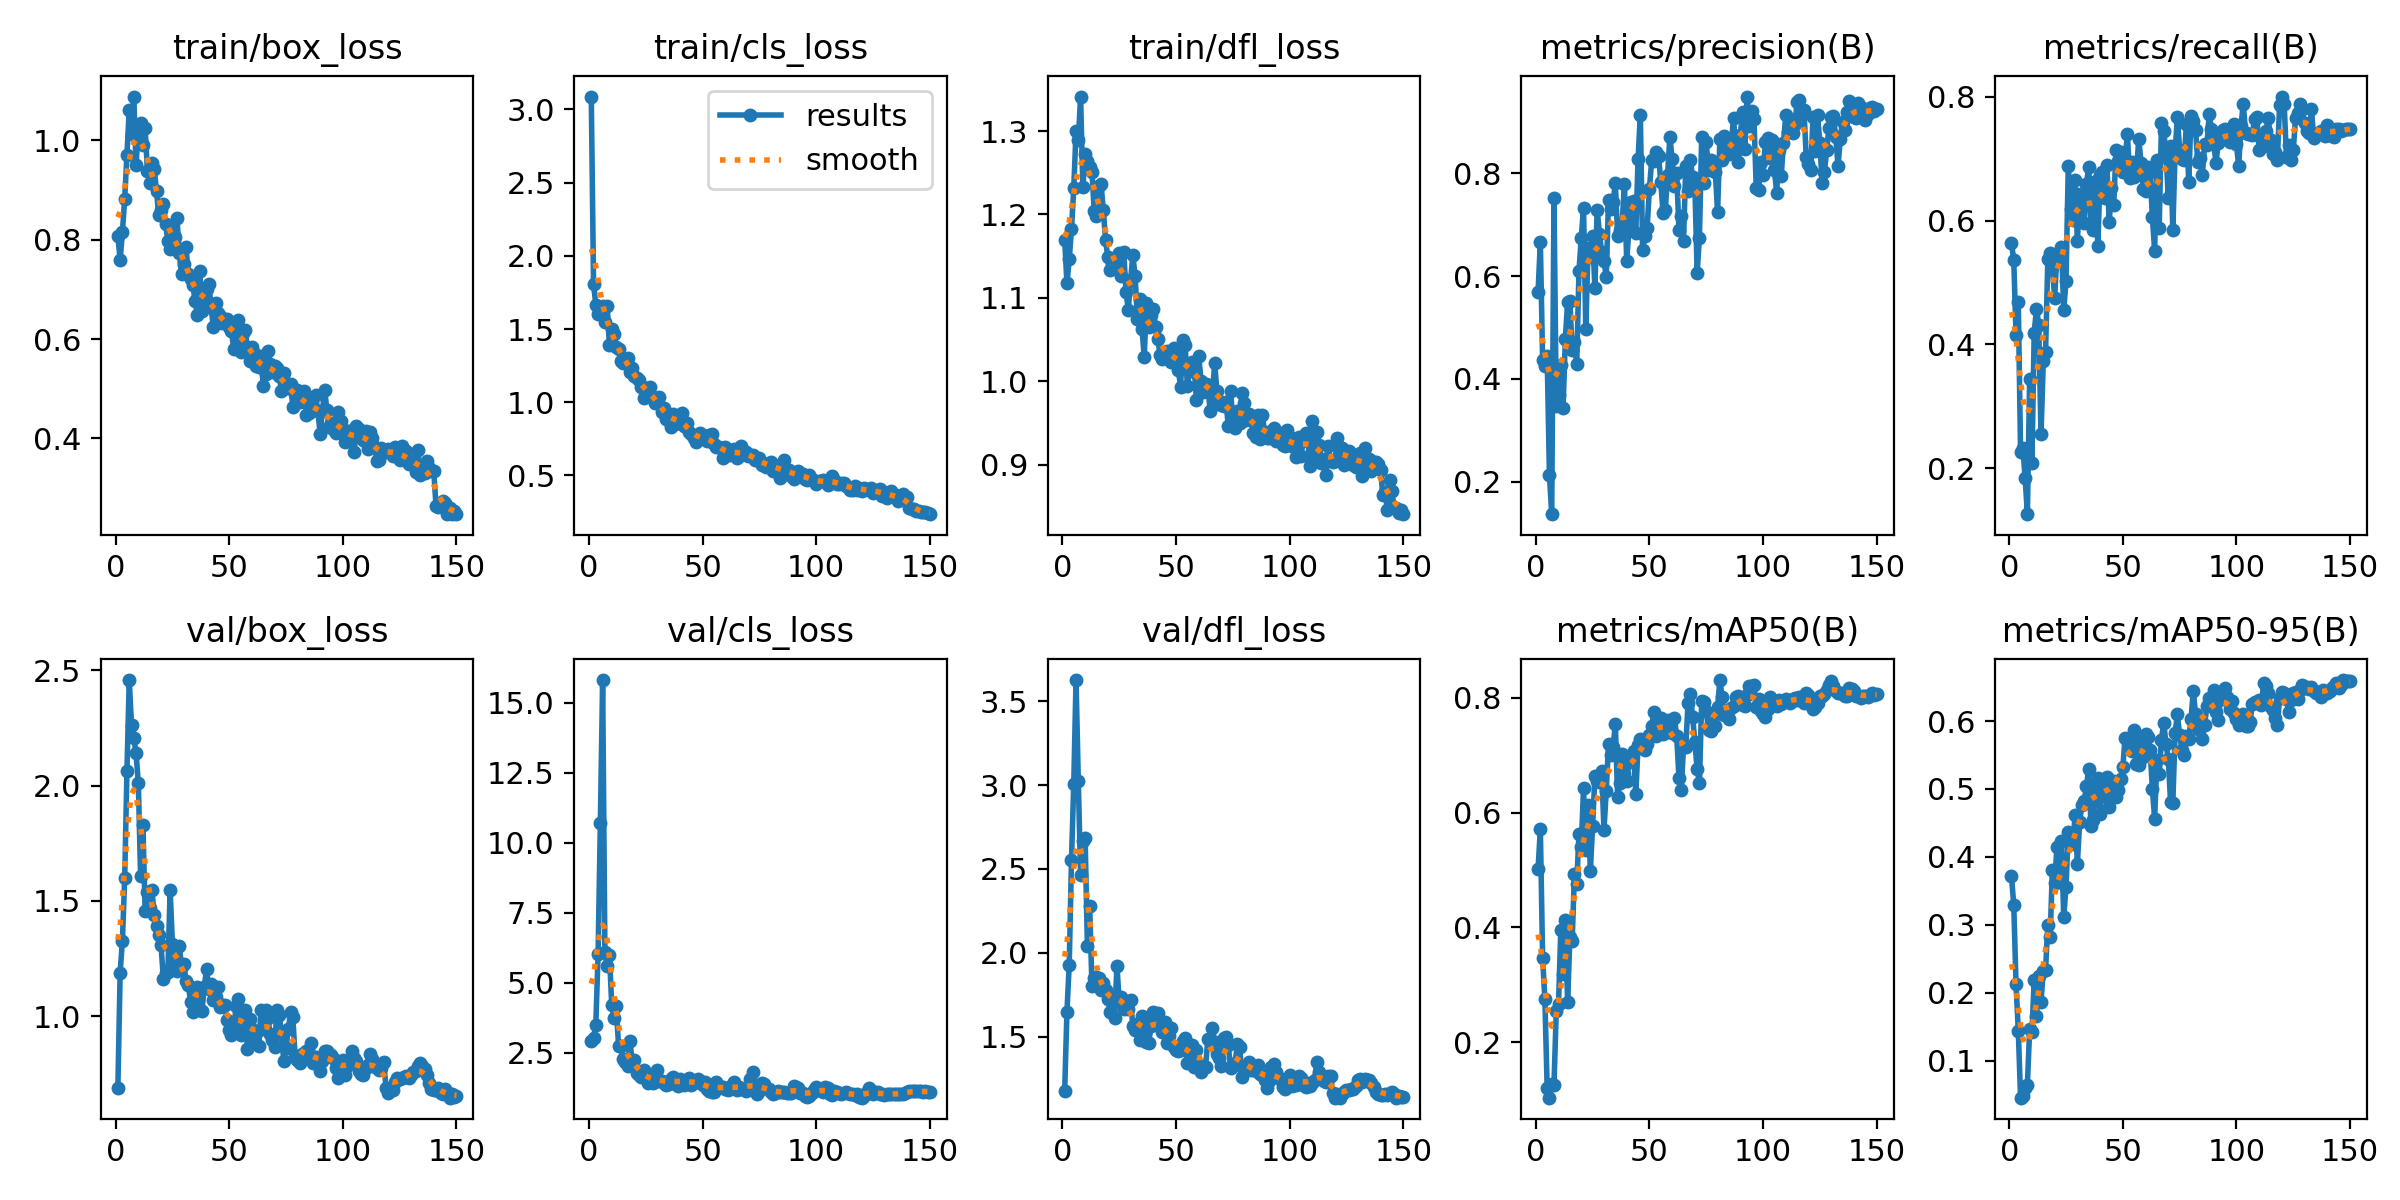

In [9]:
Image(filename=f'/content/runs/detect/train/results.png', width=1000)

In [10]:
# Create model folder to store model weights and train results
!mkdir /content/my_sixth_trained_model_v4
!cp /content/runs/detect/train/weights/best.pt /content/my_sixth_trained_model_v4/my_sixth_trained_model_v4.pt
!cp -r /content/runs/detect/train /content/my_sixth_trained_model_v4

# Zip into "my_model.zip"
%cd my_sixth_trained_model_v4
!zip /content/my_sixth_trained_model_v4.zip my_sixth_trained_model_v4.pt
!zip -r /content/my_sixth_trained_model_v4.zip train
%cd /content

/content/my_sixth_trained_model_v4
  adding: my_sixth_trained_model_v4.pt (deflated 8%)
  adding: train/ (stored 0%)
  adding: train/val_batch1_pred.jpg (deflated 5%)
  adding: train/val_batch0_labels.jpg (deflated 5%)
  adding: train/args.yaml (deflated 52%)
  adding: train/results.csv (deflated 62%)
  adding: train/BoxF1_curve.png (deflated 11%)
  adding: train/confusion_matrix.png (deflated 32%)
  adding: train/train_batch2.jpg (deflated 1%)
  adding: train/train_batch2240.jpg (deflated 3%)
  adding: train/val_batch2_pred.jpg (deflated 7%)
  adding: train/weights/ (stored 0%)
  adding: train/weights/last.pt (deflated 8%)
  adding: train/weights/best.pt (deflated 8%)
  adding: train/BoxP_curve.png (deflated 13%)
  adding: train/confusion_matrix_normalized.png (deflated 27%)
  adding: train/train_batch0.jpg (deflated 1%)
  adding: train/val_batch2_labels.jpg (deflated 7%)
  adding: train/BoxR_curve.png (deflated 13%)
  adding: train/results.png (deflated 7%)
  adding: train/train_batc

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# This takes forever for some reason, you can also just download the model from the sidebar
from google.colab import files

files.download('/content/my_sixth_trained_model_v4.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>